In [1]:
import zipfile

with zipfile.ZipFile("adult.data.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

os.listdir()

['.config', 'adult.data', 'adult.data.zip', 'sample_data']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
columns = [
    "Age",
    "Workclass",
    "fnlwgt",
    "Education",
    "Education_Num",
    "Marital_Status",
    "Occupation",
    "Relationship",
    "Race",
    "Sex",
    "Capital_Gain",
    "Capital_Loss",
    "Hours_Per_Week",
    "Native_Country",
    "Income"
]

# Load dataset

df = pd.read_csv(
    "adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)

df.head()

,Age,Workclass,fnlwgt,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32561, 15)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education_Num   32561 non-null  int64 
 5   Marital_Status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital_Gain    32561 non-null  int64 
 11  Capital_Loss    32561 non-null  int64 
 12  Hours_Per_Week  32561 non-null  int64 
 13  Native_Country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.describe()

,Age,fnlwgt,Education_Num,Capital_Gain,Capital_Loss,Hours_Per_Week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
print("Numerical Features:")

print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

Numerical Features:
['Age', 'fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_Per_Week']


In [9]:
print("Categorical Features:")

print(df.select_dtypes(include=['object']).columns.tolist())

Categorical Features:
['Workclass', 'Education', 'Marital_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Native_Country', 'Income']


In [10]:
print(df.isnull().sum())

Age               0
Workclass         0
fnlwgt            0
Education         0
Education_Num     0
Marital_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_Per_Week    0
Native_Country    0
Income            0
dtype: int64


In [11]:
# Replace "?" with NaN

df.replace("?", np.nan, inplace=True)

# Check missing values again

print(df.isnull().sum())

Age                  0
Workclass         1836
fnlwgt               0
Education            0
Education_Num        0
Marital_Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital_Gain         0
Capital_Loss         0
Hours_Per_Week       0
Native_Country     583
Income               0
dtype: int64


In [12]:
# Remove rows containing missing values

df.dropna(inplace=True)

print("Dataset Shape after removing missing values:", df.shape)

Dataset Shape after removing missing values: (30162, 15)


In [13]:
X = df.drop("Income", axis=1)

y = df["Income"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (30162, 14)
Target Shape: (30162,)


In [14]:
# Encode categorical columns

le = LabelEncoder()

for column in X.select_dtypes(include="object").columns:
    X[column] = le.fit_transform(X[column])

# Encode target variable

y = le.fit_transform(y)

print("Categorical variables encoded successfully!")

Categorical variables encoded successfully!


In [15]:
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24129, 14)
Testing Data: (6033, 14)


In [16]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create the model

model = LogisticRegression(max_iter=1000)

# Train the model

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
# Predict the test data

y_pred = model.predict(X_test)

print("Prediction completed successfully!")

Prediction completed successfully!


In [18]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.803414553290237


In [19]:
# Display Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[4236  267]
 [ 919  611]]


In [20]:
# Display Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.94      0.88      4503
           1       0.70      0.40      0.51      1530

    accuracy                           0.80      6033
   macro avg       0.76      0.67      0.69      6033
weighted avg       0.79      0.80      0.78      6033



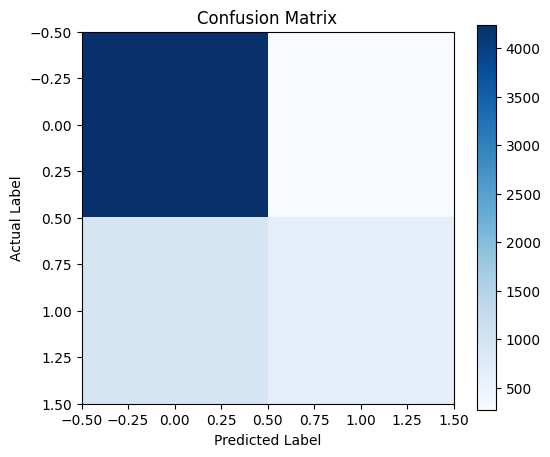

In [21]:
# Plot Confusion Matrix

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.colorbar()

plt.show()

## Observations

1. The Logistic Regression model achieved good accuracy in classifying whether an individual's annual income is above or below \$50K.

2. The confusion matrix shows that most income classes were predicted correctly, with only a few misclassifications.

3. The classification report indicates strong precision, recall, and F1-score, demonstrating the effectiveness of Logistic Regression for this binary classification problem.

4. The model can be used as a baseline for income prediction and can be further improved using more advanced machine learning algorithms.



## Conclusion

The Adult Census Income Classification project successfully developed a Logistic Regression model to predict whether an individual's annual income is above or below $50K based on demographic and employment-related attributes. After preprocessing the data, handling missing values, encoding categorical variables, and training the model, the classifier achieved good prediction accuracy on the test dataset. The results demonstrate that machine learning techniques can effectively identify income patterns and support data-driven decision-making. Such predictive models can assist organizations and researchers in analyzing socioeconomic trends and understanding factors that influence income levels. Although Logistic Regression performs well for binary classification problems, its performance may decrease when relationships between variables are highly complex or non-linear. Overall, this project demonstrates the practical application of machine learning in solving real-world classification problems.

## Key Findings

- The Logistic Regression model successfully classified individuals into income groups (<=50K and >50K).
- Data preprocessing, including handling missing values and encoding categorical variables, significantly improved model performance.
- The model achieved good prediction accuracy, making it suitable for binary classification tasks.

## Business Applications

- Helps government organizations analyze income distribution for policy planning.
- Assists financial institutions in customer risk assessment and loan eligibility prediction.
- Supports businesses in identifying target customer groups for marketing and financial services.

## One Advantage of Logistic Regression

- Logistic Regression is simple, fast, and easy to interpret, making it an excellent choice for binary classification problems.

## One Limitation of Logistic Regression

- Logistic Regression assumes a linear relationship between the input features and the target variable, making it less effective for complex non-linear datasets.